In [29]:
import numpy as np
import matplotlib.pyplot as plt
import control
g=9.81
Ts=0.005

In [30]:
class X():
    def __init__(self,state=np.zeros(6)):
        self.x,self.y,self.phi=state[0],state[1],state[2]
        self.xDot,self.yDot,self.phiDot=state[3],state[4],state[5]
    def __call__(self):
        return [self.x,self.y,self.phi,self.xDot,self.yDot,self.phiDot]




In [31]:
class Obstacle:
    def __init__(self,x,y,r):
        self.c=np.array([x,y])
        self.r=r
    def CheckCollisionThroughTime(self,state):
        nChecks=state.shape[1]
        for i in range(nChecks):
            currentState=X(state[:,i])
            if self.CheckCollision([currentState.x,currentState.y]):
                return 1
        return 0
    def CheckCollision(self,point,offset=0):
        distance=np.linalg.norm(np.array(point-self.c))
        if distance<=(self.r+offset):
            return 1
    def __call__(self):
        return self.c,self.r
    
class Node():
    def __init__(self,parent=None,pos=None,g=0,h=0):
        self.parent = parent
        self.pos=pos
        self.g,self.h=g,h
        self.f=self.g+self.h
    def __eq__(self,other):
        return self.pos==other.pos
    def __hash__(self):
        return hash(self.pos)
    def __lt__(self,other):
        return self.f<other.f

In [32]:
A = np.zeros([6,6])
A[0,3]=1
A[1,4]=1
A[2,5]=1
A[3,2]=-9.81

m=0.18
J=1.5*10**-4
L=0.086

B=np.zeros([6,2])
B[4,0]=1/m
B[5,1]=1/J
print(A,B)
Q=np.diag([1,10,50,1,1,10])
R=np.diag([0.1,1])

sys_d = control.c2d(control.ss(A, B, np.eye(6), np.zeros((6,2))), Ts=Ts)
Ad, Bd = sys_d.A, sys_d.B
K, _, _ = control.dlqr(Ad, Bd, Q, R)
print(K)

[[ 0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    1.    0.  ]
 [ 0.    0.    0.    0.    0.    1.  ]
 [ 0.    0.   -9.81  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]] [[0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [5.55555556e+00 0.00000000e+00]
 [0.00000000e+00 6.66666667e+03]]
[[-9.98304594e-14  9.50083861e+00  5.39591656e-13 -1.46232683e-13
   3.52801578e+00  1.34323992e-15]
 [-9.38928412e-03 -4.27499517e-16  1.22751610e-01 -1.79759038e-02
   2.68838049e-17  3.03035000e-02]]


In [33]:
class Sigma:
    def __init__(self,k=1,limit=1):
        self.k=k
        self.limit=limit
    def val(self,s):
        return self.limit*np.tanh(self.k*s)
    def prime(self,s):
        return self.limit*self.k*(1-np.tanh(self.k*s)**2)
    def dPrime(self,s):
        tanh_s = np.tanh(self.k * s)
        return -2 * self.limit * (self.k**2) * tanh_s * (1 - tanh_s**2)

In [ ]:
from cvxopt import matrix,solvers
solvers.options['show_progress']=False
class CBFQPController:
    def __init__(self, nominal_controller, m, J, gamma=5.0, alpha=1.0):
        self.nominal = nominal_controller 
        self.m = m
        self.J = J
        self.gamma = gamma #decay rate
        self.alpha = alpha #class-kappa fnct
        self.sigma = Sigma(k=0.5, limit=5.0) #smooth non-linear function choice, needs tuning
    def cbfConstraint(self,state,obstacles):
        G=[]
        H=[]
        for obs in obstacles:
            rSafe=obs.r+5
            rx,ry=state.x-obs.c[0],state.y-obs.c[1]
            s = -(rx)*np.sin(state.phi) + (ry)*np.cos(state.phi)
            p = (rx)*np.cos(state.phi) + (ry)*np.sin(state.phi)
            v = -state.xDot*np.sin(state.phi) + state.yDot*np.cos(state.phi)
            w =  state.xDot*np.cos(state.phi) + state.yDot*np.sin(state.phi)
            ds = v - p*state.phiDot
            h = (rx**2 + ry**2) - rSafe**2
            hDot = 2*(rx*state.xDot + ry*state.yDot)
            sig=self.sigma.val(s)
            sigP=self.sigma.prime(s)
            sigPP=self.sigma.dPrime(s)
            gHat=h-sig
            gHatDot=hDot-sigP*ds
            hAug=gHatDot+self.gamma*gHat
            C=-2*g*ry+g*sigP*np.cos(state.phi)+2*(state.xDot**2+state.yDot**2)-sigPP*(ds**2)+sigP*(2*w*state.phiDot+s*(state.phiDot**2))+self.gamma*gHatDot
            Lg1 = (1/self.m) * (2*s - sigP)
            Lg2 = (p * sigP) / self.J
            G.append([-Lg1, -Lg2])
            H.append(C + self.alpha * hAug)
        y_floor = 2.0 
        gamma_floor = 2.0 
        
        h_floor = state.y - y_floor
        h_dot_floor = state.yDot
        Lg_floor = [-np.cos(state.phi) / self.m, 0]
        boundary_floor = -g + 2 * gamma_floor * h_dot_floor + (gamma_floor**2) * h_floor
        if state.y < 50:
            G.append(Lg_floor)
            H.append(boundary_floor)
            
        y_ceil = 445.0
        h_ceil = y_ceil - state.y
        h_dot_ceil = -state.yDot
        
        Lg_ceil = [np.cos(state.phi) / self.m, 0]
        boundary_ceil = g + 2 * gamma_floor * h_dot_ceil + (gamma_floor**2) * h_ceil
        
        if state.y > 400.0:
            G.append(Lg_ceil)
            H.append(boundary_ceil)

        return np.array(G), np.array(H)
    def Controller(self,desiredState,state,obstacles):
        u_nom = np.array(self.nominal.Controller(desiredState, state),dtype=np.float64)
        P = matrix(np.eye(2))
        q = matrix(-u_nom)
        G_np, h_np = self.cbfConstraint(state, obstacles)
        u_max = np.array([2*self.m*g, 1])
        u_min = np.array([0,-1])
        G_sat = np.array([[1,0],[-1,0],[0,1],[0,-1]])
        h_sat = np.array([u_max[0],-u_min[0],u_max[1],-u_min[1]])
        if len(G_np) > 0:
            G_final = matrix(np.vstack([G_np, G_sat]))
            h_final = matrix(np.hstack([h_np, h_sat]))
        else:
            G_final = matrix(G_sat)
            h_final = matrix(h_sat)

        try:
            sol = solvers.qp(P, q, G_final, h_final)
            u_safe = np.array(sol['x']).flatten()
            if sol['status']!='optimal':
                print("Unoptimal QP")
                raise ArithmeticError
            return u_safe
        except (ValueError, ArithmeticError):
            u_nom = np.array(self.nominal.Controller(X(np.array([state.x,state.y,0,0,0,0])), state),dtype=np.float64)
            u1=np.clip(u_nom[0],u_min[0],u_max[0])
            u2=np.clip(u_nom[1],u_min[1],u_max[1])
            return np.array([u1, u2])

In [35]:
thrustLimit=2
class PDController:
    def __init__(self,Kp1,Kd1,Kp2,Kd2,Kp3,Kd3,m):
        self.Kp1=Kp1
        self.Kp2=Kp2
        self.Kd1=Kd1
        self.Kd2=Kd2
        self.Kp3=Kp3
        self.Kd3=Kd3
        self.mass=m
        self.phiDesLast=0
    '''
    def Controller(self,xDes,yDes,state,dt,saturate=True):
        u1=self.mass*g+self.Kp1*(yDes-state.y)+self.Kd1*(-state.yDot)
        phiDes=self.Kp2*(xDes-state.x)+self.Kd2*(-state.xDot)
        phiDesDot=(phiDes-self.phiDesLast)/dt
        u2=self.Kp3*(phiDes-state.phi)+self.Kd3*(phiDesDot-state.phiDot)
        self.phiDesLast=phiDes
        if saturate:
            u1 = np.clip(u1,0,thrustLimit*self.mass*g)
            u2 = np.clip(u2,-1.0,1.0)
        return [u1,u2]
    '''
    def Controller(self,desiredState,state,saturate=True):
        axDes=self.Kp2*(desiredState.x-state.x)+self.Kd2*(desiredState.xDot-state.xDot)
        ayDes=self.mass*g+self.Kp1*(desiredState.y-state.y)+self.Kd1*(desiredState.yDot-state.yDot)
        Fvertical=self.mass*(ayDes+g)
        FHorizontal=self.mass*axDes
        u1=np.sqrt(FHorizontal**2+Fvertical**2)
        phiDes=np.arctan2(-FHorizontal,Fvertical)
        phiErr=phiDes-state.phi
        u2=self.Kp3*phiErr+self.Kd3*(-state.phiDot)
        if saturate:
            u1 = np.clip(u1,0,thrustLimit*self.mass*g)
            u2 = np.clip(u2,-1.0,1.0)
        return [u1,u2]
class LQRController:
    def __init__(self,uEq,m,K=K):
        self.K=K
        self.uEq=uEq
        self.mass=m
    def Controller(self,desiredState,state):
        error=np.array(state())-np.array(desiredState())
        #error = np.clip(error, -5.0, 5.0)
        u=np.array(self.uEq)-self.K@(error)
        return u

In [36]:
from scipy.integrate import solve_ivp
goalWidth=20
XLim=800
floor=0
cieling=450


class Quadcopter:
    def __init__(self,m,L,J,state=np.zeros(6)):
        self.M=0    #Moment (ie rotation)
        self.L=L
        self.mass=m
        self.torque=J
        self.F=self.mass*g    #Forward Thrust, EQ point
        self.state=X(state)
        self.diffState=None
        NominalController=LQRController([self.mass*g,0],self.mass)
        self.Controller=CBFQPController(NominalController, m, J, gamma=1, alpha=5.0)
        #self.Controller=PDController(4,3.6,2.25,2.7,0.094,0.006,self.mass)
        self.Trajectory=None
        self.current=None
    def dynamics(self,inputs,state):
        state=X(state)
        self.F,self.M=inputs
        xDDot=-self.F/self.mass*np.sin(state.phi)
        yDDot=self.F/self.mass*np.cos(state.phi)-g
        phiDDot=self.M/self.torque
        self.diffState=X([state.xDot,state.yDot,state.phiDot,xDDot,yDDot,phiDDot])
        return self.diffState()
    def solve(self,inputs,nSim=[0,15],nChecks=1000):
        nEval = np.linspace(nSim[0],nSim[1],nChecks)
        solution=solve_ivp(fun=lambda t, state: self.dynamics(inputs,state),
                           t_span=nSim,
                           t_eval=nEval,
                           y0=self.state()
                           )
        self.state= X(solution.y[:, -1])
        return solution.y
    
    def stepRk4(self,inputs,dt):
        k1 = np.array(self.dynamics(inputs, self.state()))
        k2 = np.array(self.dynamics(inputs, self.state() + 0.5 * dt * k1))
        k3 = np.array(self.dynamics(inputs, self.state() + 0.5 * dt * k2))
        k4 = np.array(self.dynamics(inputs, self.state() + dt * k3))
        newState = X(self.state() + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4))
        self.state=newState
       

    def trackTrajectory(self,vectorField,dt,obstacles):
        stateHistory=list()
        stateHistory.append(self.state())
        dt=dt
        t=0
        self.current=True
        while not vectorField.isDone(self.state):
            targetState=vectorField(self.state)
            print("Targets", targetState.x,targetState.y)
            inputs=self.Controller.Controller(targetState,self.state,obstacles)
            self.stepRk4(inputs,dt)
            print(self.state.x, self.state.y)
            stateHistory.append(self.state())
            t+=dt 
            if t > 120 or self.state.y<0: 
                print("Timeout: Drone likely stuck in local minimum.")
                break
        return np.array(stateHistory).T

    

In [37]:
class GoalVectorField:
    def __init__(self,goal,goalWidth,maxSpeed=10):
        self.goal=np.array(goal)
        self.maxSpeed=maxSpeed
        self.threshold=goalWidth
    def __call__(self,currentState):
        pos = np.array([currentState.x, currentState.y])
        vec = self.goal - pos
        distance = np.linalg.norm(vec)
        if distance < self.threshold:
            velDes = np.array([0.0, 0.0])
            posDes = self.goal
        else:
            unitVec = vec / distance
            velDes = unitVec * self.maxSpeed
            posDes=unitVec*2+pos
        return X(np.array([posDes[0], posDes[1], 0, velDes[0], velDes[1], 0]))
    def isDone(self, currentState):
        dist = np.linalg.norm(self.goal - np.array([currentState.x, currentState.y]))
        return dist < self.threshold

In [38]:
class SimulationEnviroment:
    def __init__(self,goal=[250,200]):
        self.obstacle=list()
        self.goal=Obstacle(goal[0],goal[1],goalWidth)
        self.vector=GoalVectorField(goal,goalWidth)
    def CreateObstacle(self,x,y,r):
        self.obstacle.append(Obstacle(x,y,r))
    def checkSolution(self,solution):
        if (solution[1]<floor).any():
            print("Crashed into the ground")
            #return None
        elif (solution[1]>cieling).any():
            print("Crashed into the cieling")
        for obstacle in self.obstacle:
            if obstacle.CheckCollisionThroughTime(solution):
                print("Crashed into an obstacle")
                #return None
        if self.goal.CheckCollisionThroughTime(solution):
            print("Reached Goal")
        if (solution[0]>XLim).any() or (solution[0]<0).any() :
            print("Crashed into the walls")
    def PlotObjects(self,ax):
        for obstacle in self.obstacle:
            c,r=obstacle()
            circle=plt.Circle((c[0],c[1]),r,color="red",alpha=0.7)
            ax.add_patch(circle)
        c,r=self.goal()   
        circle=plt.Circle((c[0],c[1]),r,color="green",alpha=0.7)
        ax.add_patch(circle)


In [39]:
#Quadcopter and base simulation
m=0.18
J=1.5*10**-4
L=0.086 #Kg,m,Kgm^2
Quad=Quadcopter(m,L,J)
Env=SimulationEnviroment(goal=[650,400])
Env.CreateObstacle(100,250,100)
Env.CreateObstacle(300,250,75)

Env.CreateObstacle(500,300,100)
Env.CreateObstacle(700,200,75)
Env.CreateObstacle(600,50,115)#sol=Quad.solve([m*g,0],nChecks=1000) #Inputs, and number of checks
#Env.checkSolution(sol)

In [40]:
traj=Env.vector
sol=Quad.trackTrajectory(traj,dt=Ts,obstacles=Env.obstacle)
Env.checkSolution(sol)

Targets 1.703316633409088 1.0481948513286694
5.759015996983076e-07 0.00012262296991071532
Targets 1.7033173523232759 1.0483172419030886
8.6261988076024e-06 0.0004904130958660527
Targets 1.7033258270151188 1.0486843423872383
3.723796639872436e-05 0.0011029908835245013
Targets 1.7033551346954812 1.0492957893144312
9.978975967359046e-05 0.001959613076893873
Targets 1.7034186434204923 1.05015085648794
0.00020935605300246454 0.003059198127670755
Targets 1.7035294169886204 1.0512484797053272
0.0003787014368891938 0.004400349168044953
Targets 1.703700209168836 1.052587279680808
0.00062027606177652 0.00598137637593411
Targets 1.703943459173904 1.0541655843626656
0.0009462122289386173 0.007800318890044798
Targets 1.7042712882794007 1.0559814508026963
0.00136832196979893 0.009854966036555222
Targets 1.7046954974296396 1.0580326863397491
0.0018980955742692728 0.01214287781917594
Targets 1.70522756579106 1.0603168690491565
0.002546701068270478 0.014661404882892418
Targets 1.7058786502534957 1.0628

In [41]:
len(sol[0])*Ts

87.16

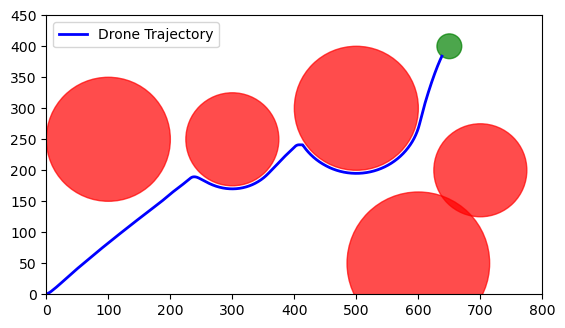

In [42]:
#Plotting
x,y=sol[0:2]
fig, ax = plt.subplots(1)
Env.PlotObjects(ax)
ax.set_aspect('equal',adjustable='box')
ax.set_ylim(floor,cieling)
ax.set_xlim(0,XLim)
ax.plot(x, y, 'b-', linewidth=2, label='Drone Trajectory')
plt.legend()
plt.show()

